In [40]:
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

nltk.download('stopwords')

def train_lotr_w2v(file_path):

    stop_words = set(stopwords.words('english'))

    with open(file_path, 'r', encoding='utf-8') as f:

        raw_text = f.read().replace('\n', ' ')

        raw_text = re.sub(r'\d+', '', raw_text)
        words = raw_text.split()

    clean_words = [w for w in words if w not in stop_words and len(w) > 2]

    sentence_length = 15
    sentences = [clean_words[i:i + sentence_length] for i in range(0, len(clean_words), sentence_length)]
    
    model_sg = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=2,
        workers=4,
        sg=1,
        epochs=10
    )

    return sentences, model_sg

sentences, model_sg = train_lotr_w2v('The_Fellowship_Of_The_Ring.txt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Gamer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:

def cos_sim(model_sg, target_word):
    if target_word not in model_sg.wv:
        return None
    
    target_vec = model_sg.wv[target_word]
    similar = []
    
    for word in model_sg.wv.index_to_key:
        if word == target_word:
            continue
        temp_vec = model_sg.wv[word]
        score = np.dot(target_vec, temp_vec) / (np.linalg.norm(target_vec) * np.linalg.norm(temp_vec))
        similar.append((word, score))
    
    similar.sort(key=lambda x: x[1], reverse=True)
    return similar[:5]


In [42]:
def visualize_cbow(sentences, n_words=30):
    model_cbow = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=5, sg=0, epochs=15)
    
    words = model_cbow.wv.index_to_key[:n_words]
    word_vectors = np.array([model_cbow.wv[w] for w in words])
    
    pca = PCA(n_components=2)
    result = pca.fit_transform(word_vectors)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])
    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()

Top 5 for 'frodo': [('wizard', np.float32(0.9185492)), ('smile', np.float32(0.88781476)), ('farmer', np.float32(0.88208485)), ('thoughtfully', np.float32(0.8636427)), ('surprise', np.float32(0.8629844))]


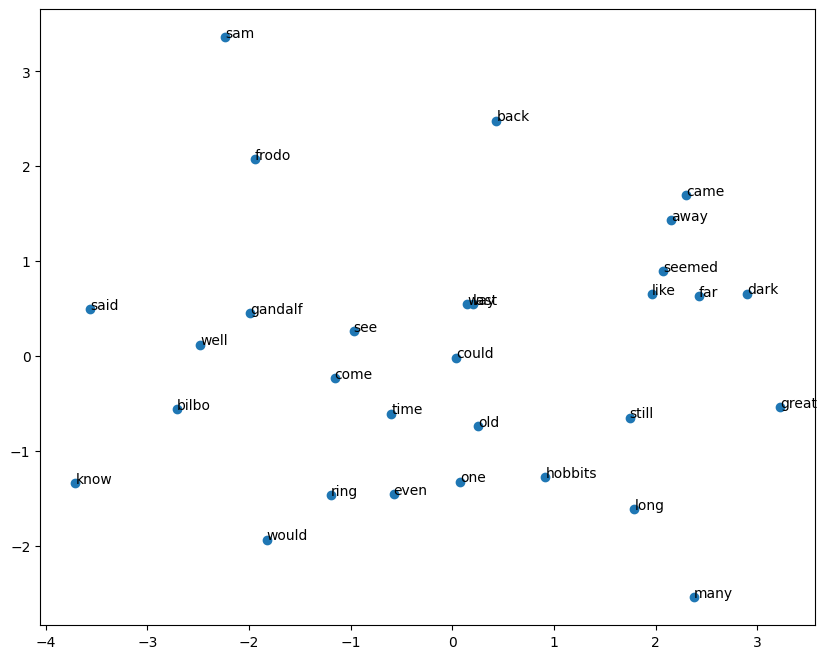

0.66132027


: 

In [ ]:
target = "frodo"
print(f"Top 5 for '{target}': {cos_sim(model_sg, target)}")
visualize_cbow(sentences, n_words=30)
